# PE-Core-L14-336 NPU 추론 데모 (Jupyter)

Mobilint ARIES NPU로 PE 비전인코더를 추론하고, **이미지 간 유사도**와 **원본 PyTorch 대비 정확도(cos)**를
셀 단위로 확인하는 노트북. 무거운 24 transformer block은 NPU(INT8), 작은 attn_pool head는 CPU(float)인
**hybrid** 구조다 (원본 대비 cos 0.997).

### 사전 준비 (이 노트북 실행 전에 끝나 있어야 함)
1. **NPU 환경 세팅** — 드라이버/런타임/CLI. `.claude/skills/npu-setup` 또는 `setup/` 참고.
   `mobilint-cli status`로 `/dev/aries0`가 보이면 OK.
2. **conda 환경** — `bash setup/setup_conda_host.sh` (qbruntime + torch/einops/timm/huggingface_hub + matplotlib).
   이 노트북은 그 env 커널로 실행한다.
3. **trunk MXQ** — `pe_npu/out/pe_feat.mxq`. 없으면 `tutorial_pe_npu/README.md`의 calib/compile 단계 먼저.

> 설치·컴파일 같은 시스템/CLI 단계는 노트북에 부적합하므로 README/skill에 두고, 이 노트북은 **추론·검증**만 다룬다.

## 0. 환경 체크
필요한 게 다 있는지(패키지/NPU 디바이스/MXQ) 먼저 확인한다. 하나라도 빠지면 위 사전 준비로 돌아간다.

In [1]:
import os, sys, glob
sys.path.insert(0, os.path.abspath(".."))  # tutorial_pe_npu/ -> AX_NPU/AX_NPU (import pe_npu)

import numpy as np

# (libqbruntime이 ldconfig에 등록돼 있으면 불필요. 미등록 환경이면 아래 주석 해제)
# os.environ["LD_LIBRARY_PATH"] = "/.../qbruntime/qbruntime/lib:" + os.environ.get("LD_LIBRARY_PATH", "")

import pe_npu
from pe_npu.inference import DEFAULT_FEAT_MXQ

print("pe_npu OK:", pe_npu.__all__)
print("/dev/aries0:", "있음" if os.path.exists("/dev/aries0") else "없음 (NPU 미장착/드라이버 확인)")
print("MXQ:", DEFAULT_FEAT_MXQ, "->", "있음" if os.path.exists(DEFAULT_FEAT_MXQ) else "없음 (컴파일 필요)")

pe_npu OK: ['preprocess_image', 'IMAGE_SIZE', 'load_pe', 'apply_pe_patches', 'VisionWrapper', 'FeatWrapper', 'PoolWrapper', 'MXQInferenceHybrid']
/dev/aries0: 있음
MXQ: /home/gpuadmin/Repo/seoik/AX_NPU/AX_NPU/pe_npu/out/pe_feat.mxq -> 있음


## 1. 예제 이미지 준비
공개 COCO 이미지 5장. 이미 있으면 그대로 쓰고, 없으면 다운로드한다.

In [2]:
IMAGES_DIR = "./images"
paths = sorted(glob.glob(os.path.join(IMAGES_DIR, "*.jpg")) + glob.glob(os.path.join(IMAGES_DIR, "*.png")))
if not paths:
    import download_images  # tutorial_pe_npu/download_images.py 실행
    paths = sorted(glob.glob(os.path.join(IMAGES_DIR, "*.jpg")) + glob.glob(os.path.join(IMAGES_DIR, "*.png")))
names = [os.path.basename(p) for p in paths]
print(f"이미지 {len(paths)}장:", names)

이미지 5장: ['bus.jpg', 'cat1.jpg', 'cat2.jpg', 'dog.jpg', 'pizza.jpg']


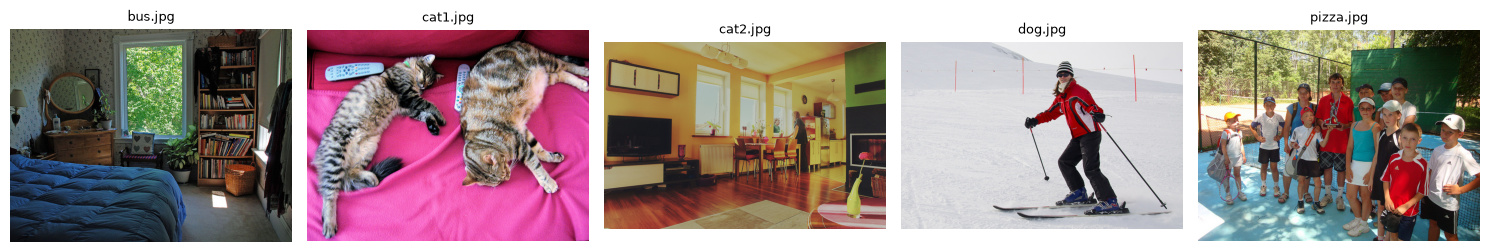

In [3]:
# 이미지 미리보기 (노트북의 장점: 인라인 시각화)
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(1, len(paths), figsize=(3*len(paths), 3))
for ax, p, n in zip(np.atleast_1d(axes), paths, names):
    ax.imshow(Image.open(p).convert("RGB")); ax.set_title(n, fontsize=9); ax.axis("off")
plt.tight_layout(); plt.show()

## 2. 전처리 + NPU 추론
`pe_npu.preprocess_image`(resize 336 + normalize 0.5) 후 `MXQInferenceHybrid`로 임베딩(1024-d)을 뽑는다.
`infer`는 NPU trunk(INT8) -> CPU pool/proj(float)를 한 번에 처리한다.

In [4]:
x = np.stack([pe_npu.preprocess_image(p) for p in paths], axis=0)  # (N,3,336,336) float32
print("입력 배치:", x.shape, x.dtype)

npu = pe_npu.MXQInferenceHybrid(DEFAULT_FEAT_MXQ)
emb_npu = npu.infer(x)   # (N,1024)
print("NPU 임베딩:", emb_npu.shape)

입력 배치: (5, 3, 336, 336) float32
I0617 11:20:35.160 3131318 model_impl.cc:1025] Model constructed. (/home/gpuadmin/Repo/seoik/AX_NPU/AX_NPU/pe_npu/out/pe_feat.mxq) 
I0617 11:20:35.335 3131318 model_impl.cc:1357] Model launched.
Missing keys for loading model: []
Unexpected keys for loading model: []
NPU 임베딩: (5, 1024)


## 3. 이미지 간 유사도
임베딩을 정규화해 코사인 유사도 매트릭스를 만든다. 비슷한 이미지(고양이 2장)는 높고, 다른 종류는 낮아야 정상이다.

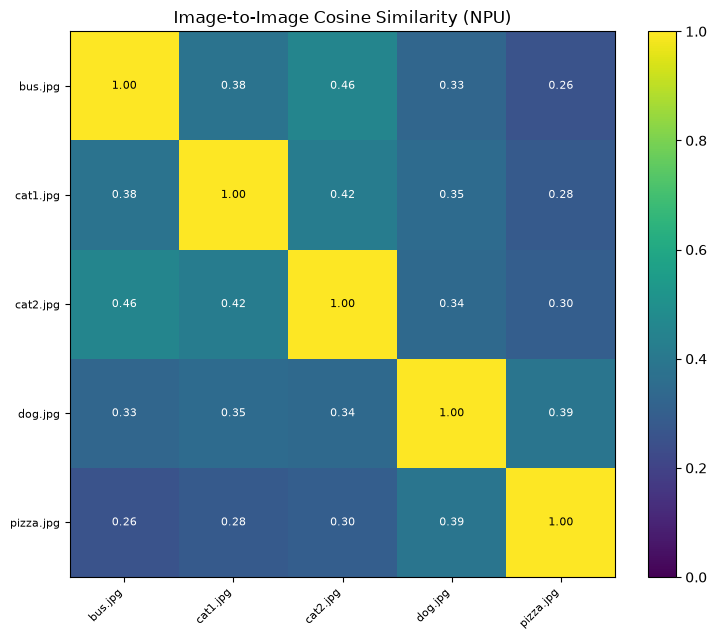

In [5]:
def l2norm(a):
    return a / (np.linalg.norm(a, axis=-1, keepdims=True) + 1e-9)

E = l2norm(emb_npu)
S = E @ E.T  # (N,N) 코사인 유사도

fig, ax = plt.subplots(figsize=(1.1*len(paths)+2, 1.1*len(paths)+1))
im = ax.imshow(S, vmin=0, vmax=1, cmap="viridis")
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=8)
for i in range(len(names)):
    for j in range(len(names)):
        ax.text(j, i, f"{S[i,j]:.2f}", ha="center", va="center",
                color="white" if S[i,j] < 0.6 else "black", fontsize=8)
ax.set_title("Image-to-Image Cosine Similarity (NPU)"); fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

## 4. 원본 PyTorch 대비 정확도
양자화 손실 확인. 원본 PE(미패치, float)로 같은 이미지를 추론해 NPU 임베딩과 cos를 비교한다.
평균 0.99+ 면 양자화가 잘 된 것 (검증값 0.997).

In [6]:
import torch
ref = pe_npu.load_pe("PE-Core-L14-336", mode="full", patch=False)  # 원본 float 기준
with torch.no_grad():
    emb_pth = ref(torch.from_numpy(x)).numpy()

def cos(a, b):
    a, b = a.ravel(), b.ravel()
    return float(a @ b / (np.linalg.norm(a)*np.linalg.norm(b) + 1e-9))

per = [cos(emb_pth[i], emb_npu[i]) for i in range(len(paths))]
mean_cos = float(np.mean(per))
for n, c in zip(names, per):
    print(f"  {n:>12}: cos={c:.4f}")
print(f"\n평균 cos = {mean_cos:.4f}  ({'OK (>=0.99)' if mean_cos >= 0.99 else '점검 필요'})")

Missing keys for loading model: []
Unexpected keys for loading model: []
       bus.jpg: cos=0.9979
      cat1.jpg: cos=0.9987
      cat2.jpg: cos=0.9950
       dog.jpg: cos=0.9968
     pizza.jpg: cos=0.9982

평균 cos = 0.9973  (OK (>=0.99))


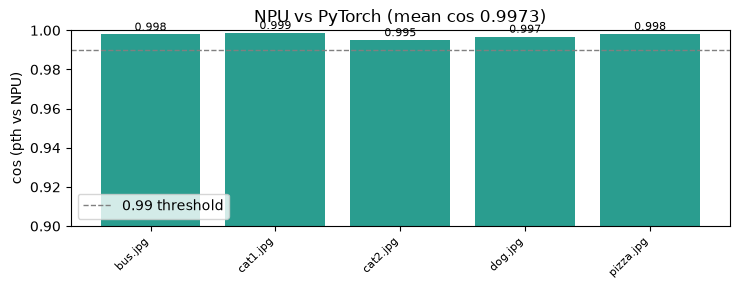

In [7]:
fig, ax = plt.subplots(figsize=(1.1*len(paths)+2, 3))
bars = ax.bar(names, per, color=["#2a9d8f" if c >= 0.99 else "#e76f51" for c in per])
ax.axhline(0.99, ls="--", c="gray", lw=1, label="0.99 threshold")
ax.set_ylim(0.9, 1.0); ax.set_ylabel("cos (pth vs NPU)")
ax.set_title(f"NPU vs PyTorch (mean cos {mean_cos:.4f})")
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=45, ha="right", fontsize=8); ax.legend()
for b, c in zip(bars, per):
    ax.text(b.get_x()+b.get_width()/2, c+0.002, f"{c:.3f}", ha="center", fontsize=8)
plt.tight_layout(); plt.show()

## 5. 내 코드에서 쓰기
운영 코드에선 이 3줄이면 된다 (`TRTInference`와 동일 인터페이스 `model.infer(x) -> (B,1024)`):

```python
import pe_npu, numpy as np
model = pe_npu.MXQInferenceHybrid()                 # 기본 MXQ = pe_npu/out/pe_feat.mxq
x = np.stack([pe_npu.preprocess_image(p) for p in paths])  # (B,3,336,336)
emb = model.infer(x)                                # (B,1024)
```

전체 배경/원리: `../reports/SOLUTION_single_io_compile.md`.